Steepest Descent Result
Final x = [0.9999845  0.99999358 0.        ]
Final cost = 10.000000001639815
Iterations = 5000


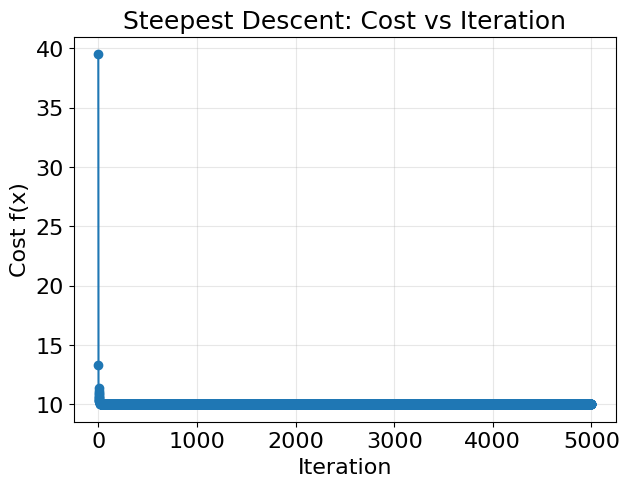

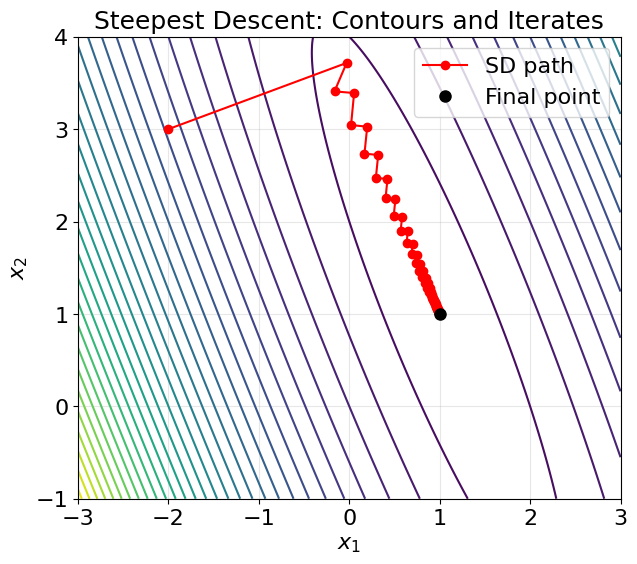

In [23]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'legend.fontsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16
})

def f(x):
    x1, x2, x3 = x
    return 5*x1**2 + x2**2 + 2*x3**2 + 4*x1*x2 - 14*x1 - 6*x2 + 20

def grad(x):
    x1, x2, x3 = x
    return np.array([
        10*x1 + 4*x2 - 14,
        4*x1 + 2*x2 - 6,
        4*x3
    ], dtype=float)

def dphi(alpha, x, d):
    return grad(x + alpha*d) @ d

def bisection_line_search(x, d, tol=1e-8, max_iter=100):
    a = 0.0
    b = 1.0

    while dphi(b, x, d) < 0:
        b *= 2.0

    for _ in range(max_iter):
        m = 0.5 * (a + b)
        val = dphi(m, x, d)

        if abs(val) < tol:
            return m
        elif val < 0:
            a = m
        else:
            b = m

    return 0.5 * (a + b)

x = np.array([-2.0, 3.0, 1.5])

path = [x.copy()]
costs = [f(x)]

tol = 1e-8
max_iter = 5000

for _ in range(max_iter):
    g = grad(x)
    if np.linalg.norm(g) < tol:
        break

    d = -g
    alpha = bisection_line_search(x, d)
    x = x + alpha*d

    path.append(x.copy())
    costs.append(f(x))

path = np.array(path)

print("Steepest Descent Result")
print("Final x =", x)
print("Final cost =", f(x))
print("Iterations =", len(costs) - 1)

plt.figure(figsize=(7, 5))
plt.plot(range(len(costs)), costs, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Cost f(x)")
plt.title("Steepest Descent: Cost vs Iteration")
plt.grid(True, alpha=0.3)
plt.show()

x1_vals = np.linspace(-3, 3, 300)
x2_vals = np.linspace(-1, 4, 300)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = 5*X1**2 + X2**2 + 4*X1*X2 - 14*X1 - 6*X2 + 20

plt.figure(figsize=(7, 6))
plt.contour(X1, X2, Z, levels=30)
plt.plot(path[:, 0], path[:, 1], 'ro-', label='SD path')
plt.plot(path[-1, 0], path[-1, 1], 'ko', markersize=8, label='Final point')
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Steepest Descent: Contours and Iterates")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Newton Result
Final x = [1. 1. 0.]
Final cost = 10.0
Iterations = 1


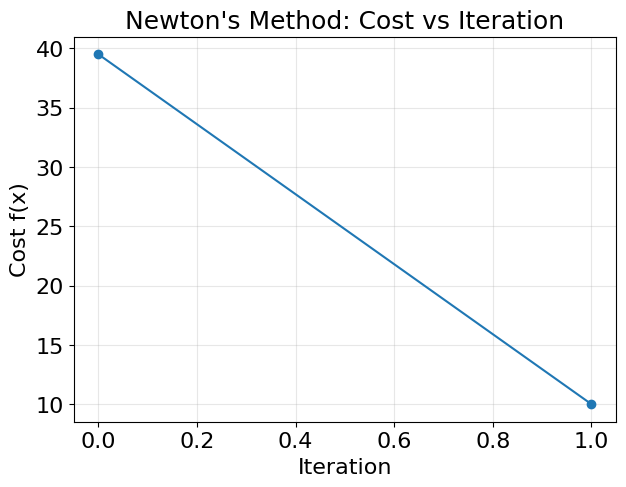

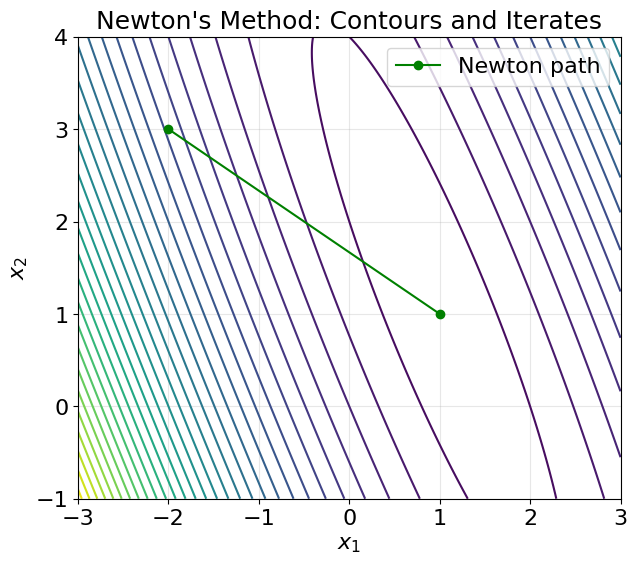

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    x1, x2, x3 = x
    return 5*x1**2 + x2**2 + 2*x3**2 + 4*x1*x2 - 14*x1 - 6*x2 + 20

def grad(x):
    x1, x2, x3 = x
    return np.array([
        10*x1 + 4*x2 - 14,
        4*x1 + 2*x2 - 6,
        4*x3
    ], dtype=float)

H = np.array([
    [10, 4, 0],
    [4,  2, 0],
    [0,  0, 4]
], dtype=float)

x = np.array([-2.0, 3.0, 1.5])
path = [x.copy()]
costs = [f(x)]

tol = 1e-8
max_iter = 20

for _ in range(max_iter):
    g = grad(x)
    if np.linalg.norm(g) < tol:
        break

    p = -np.linalg.solve(H, g)
    x = x + p

    path.append(x.copy())
    costs.append(f(x))

path = np.array(path)

print("Newton Result")
print("Final x =", x)
print("Final cost =", f(x))
print("Iterations =", len(costs) - 1)

plt.figure(figsize=(7, 5))
plt.plot(range(len(costs)), costs, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Cost f(x)")
plt.title("Newton's Method: Cost vs Iteration")
plt.grid(True, alpha=0.3)
plt.show()

x1_vals = np.linspace(-3, 3, 300)
x2_vals = np.linspace(-1, 4, 300)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = 5*X1**2 + X2**2 + 4*X1*X2 - 14*X1 - 6*X2 + 20

plt.figure(figsize=(7, 6))
plt.contour(X1, X2, Z, levels=30)
plt.plot(path[:, 0], path[:, 1], 'go-', label='Newton path')
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Newton's Method: Contours and Iterates")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Conjugate Gradient Result
Final x = [ 1.00000000e+00  1.00000000e+00 -1.62370117e-15]
Final cost = 10.0
Iterations = 3


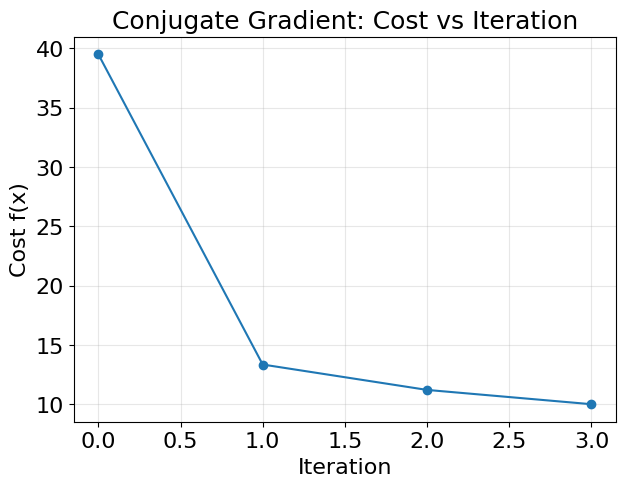

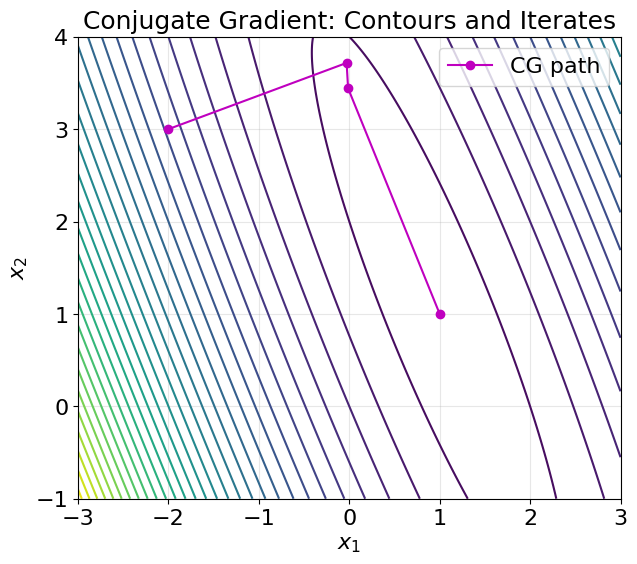

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    x1, x2, x3 = x
    return 5*x1**2 + x2**2 + 2*x3**2 + 4*x1*x2 - 14*x1 - 6*x2 + 20

def grad(x):
    x1, x2, x3 = x
    return np.array([
        10*x1 + 4*x2 - 14,
        4*x1 + 2*x2 - 6,
        4*x3
    ], dtype=float)

H = np.array([
    [10, 4, 0],
    [4,  2, 0],
    [0,  0, 4]
], dtype=float)

x = np.array([-2.0, 3.0, 1.5])
g = grad(x)
d = -g

path = [x.copy()]
costs = [f(x)]

tol = 1e-8
max_iter = 20

for _ in range(max_iter):
    if np.linalg.norm(g) < tol:
        break

    alpha = -(g @ d) / (d @ H @ d)
    x = x + alpha*d
    g_new = grad(x)

    path.append(x.copy())
    costs.append(f(x))

    if np.linalg.norm(g_new) < tol:
        g = g_new
        break

    beta = (g_new @ g_new) / (g @ g)
    d = -g_new + beta*d
    g = g_new

path = np.array(path)

print("Conjugate Gradient Result")
print("Final x =", x)
print("Final cost =", f(x))
print("Iterations =", len(costs) - 1)

plt.figure(figsize=(7, 5))
plt.plot(range(len(costs)), costs, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Cost f(x)")
plt.title("Conjugate Gradient: Cost vs Iteration")
plt.grid(True, alpha=0.3)
plt.show()

x1_vals = np.linspace(-3, 3, 300)
x2_vals = np.linspace(-1, 4, 300)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = 5*X1**2 + X2**2 + 4*X1*X2 - 14*X1 - 6*X2 + 20

plt.figure(figsize=(7, 6))
plt.contour(X1, X2, Z, levels=30)
plt.plot(path[:, 0], path[:, 1], 'mo-', label='CG path')
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Conjugate Gradient: Contours and Iterates")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()